# Cohort Retention Analysis

This notebook analyzes customer retention using monthly acquisition cohorts.

The main goals are:
- to assign customers to cohorts based on their first delivered order;
- to measure customer activity in subsequent months;
- to build a retention matrix;
- to compare retention patterns across cohorts.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from etl.config import get_engine

engine = get_engine()

pd.set_option("display.max_columns", 100)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:,.2f}",
)

sns.set_theme(
    style="whitegrid",
    context="notebook",
)

pd.read_sql(
    "SELECT current_database() AS database_name;",
    engine,
)

,database_name
0,olist_analytics


## 1. Cohort Data Preparation

In [3]:
query = """
SELECT DISTINCT
    customer_unique_id,
    order_month
FROM analytics.order_metrics
WHERE order_status = 'delivered'
  AND order_items_value IS NOT NULL
  AND customer_unique_id IS NOT NULL
ORDER BY
    customer_unique_id,
    order_month;
"""

customer_activity = pd.read_sql(query, engine)

customer_activity["order_month"] = pd.to_datetime(
    customer_activity["order_month"]
)

customer_activity.head()

,customer_unique_id,order_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-01
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-01
2,0000f46a3911fa3c0805444483337064,2017-03-01
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-01
4,0004aac84e0df4da2b147fca70cf8255,2017-11-01


In [4]:
customer_activity.shape

(95194, 2)

In [5]:
customer_activity["cohort_month"] = (
    customer_activity
    .groupby("customer_unique_id")["order_month"]
    .transform("min")
)

customer_activity.head()

,customer_unique_id,order_month,cohort_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-01,2018-05-01
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-01,2018-05-01
2,0000f46a3911fa3c0805444483337064,2017-03-01,2017-03-01
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-01,2017-10-01
4,0004aac84e0df4da2b147fca70cf8255,2017-11-01,2017-11-01


In [6]:
customer_activity["cohort_index"] = (
    (
        customer_activity["order_month"].dt.year
        - customer_activity["cohort_month"].dt.year
    )
    * 12
    + (
        customer_activity["order_month"].dt.month
        - customer_activity["cohort_month"].dt.month
    )
)

customer_activity.head()

,customer_unique_id,order_month,cohort_month,cohort_index
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-01,2018-05-01,0
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-01,2018-05-01,0
2,0000f46a3911fa3c0805444483337064,2017-03-01,2017-03-01,0
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-01,2017-10-01,0
4,0004aac84e0df4da2b147fca70cf8255,2017-11-01,2017-11-01,0


In [7]:
customer_activity["cohort_index"].describe()

count   95,194.00
mean         0.09
std          0.84
min          0.00
25%          0.00
50%          0.00
75%          0.00
max         20.00
Name: cohort_index, dtype: float64

## 2. Cohort Sizes

In [ ]:
cohort_sizes = (
    customer_activity.loc[customer_activity["cohort_index"] == 0]
    .groupby("cohort_month")
    .agg(
        customers_count=("customer_unique_id", "nunique",)
    )
    .reset_index()
)

cohort_sizes

,cohort_month,customers_count
0,2016-09-01,1
1,2016-10-01,262
2,2016-12-01,1
3,2017-01-01,717
4,2017-02-01,1628
5,2017-03-01,2503
6,2017-04-01,2256
7,2017-05-01,3451
8,2017-06-01,3037
9,2017-07-01,3752


In [9]:
cohort_sizes_filtered = cohort_sizes[
    cohort_sizes["cohort_month"].between(
        "2017-01-01",
        "2018-08-01",
    )
].copy()

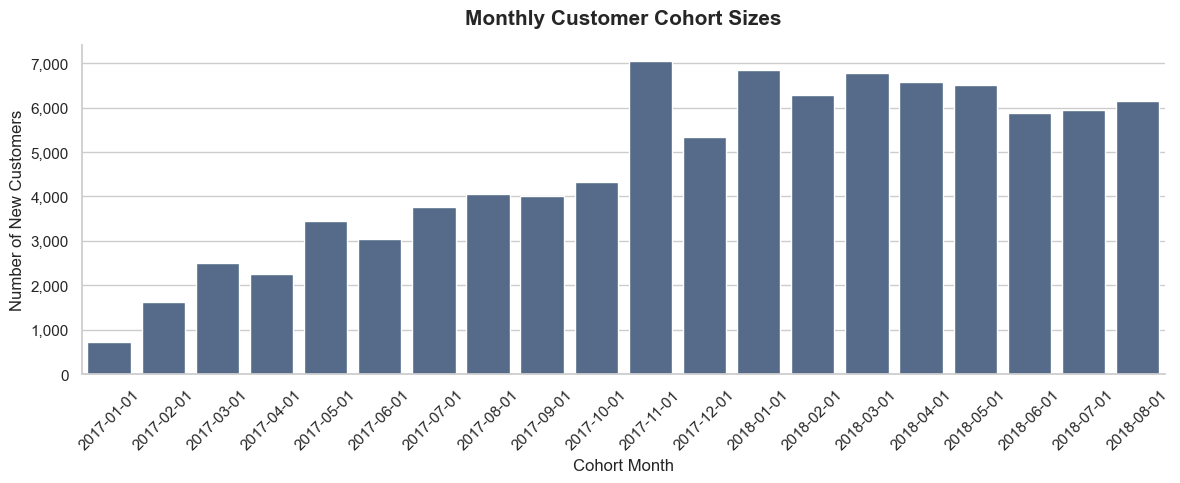

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=cohort_sizes_filtered,
    x="cohort_month",
    y="customers_count",
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "Monthly Customer Cohort Sizes",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Cohort Month")
ax.set_ylabel("Number of New Customers")

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{int(value):,}"
    )
)

sns.despine()
plt.tight_layout()
plt.show()

### Cohort size findings

The number of newly acquired customers increased substantially throughout 2017.

The January 2017 cohort contains fewer than 1,000 customers, while the November 2017 cohort exceeds 7,000 customers. This reflects the rapid growth in customer acquisition already observed in the product metrics analysis.

During 2018, cohort sizes remained relatively stable at approximately 6,000–7,000 new customers per month. This suggests that the platform moved from a rapid acquisition growth phase to a more stable level of monthly customer inflow.

The November 2017 cohort is unusually large and may reflect seasonal promotional activity. Because cohort sizes differ substantially, retention should be analyzed as a percentage of the original cohort rather than by comparing absolute customer counts.

## 3. Retention Matrix

In [12]:
cohort_counts = (
    customer_activity
    .groupby(["cohort_month", "cohort_index"]
    )
    .agg(
        customers_count=("customer_unique_id", "nunique")
    )
    .reset_index()
)

cohort_counts.head()

,cohort_month,cohort_index,customers_count
0,2016-09-01,0,1
1,2016-10-01,0,262
2,2016-10-01,6,1
3,2016-10-01,9,1
4,2016-10-01,11,1


In [13]:
retention_counts = cohort_counts.pivot(
    index="cohort_month",
    columns="cohort_index",
    values="customers_count",
)

retention_counts.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,262.00,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,1.00,NaN,1.00,NaN,1.00,NaN,1.00,NaN,1.00,2.00,2.00
2016-12-01,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,717.00,2.00,2.00,1.00,3.00,1.00,3.00,1.00,1.00,NaN,3.00,1.00,5.00,3.00,1.00,1.00,2.00,3.00,1.00,NaN
2017-02-01,"1,628.00",3.00,5.00,2.00,7.00,2.00,4.00,3.00,2.00,3.00,2.00,5.00,2.00,3.00,2.00,1.00,1.00,3.00,NaN,NaN


In [14]:
cohort_size_series = retention_counts[0]

retention_matrix = retention_counts.divide(
    cohort_size_series,
    axis=0,
)

retention_matrix.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,1.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,0.01,0.01
2016-12-01,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-02-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN


In [15]:
retention_matrix_filtered = retention_matrix.loc[
    retention_matrix.index.to_series().between(
        "2017-01-01",
        "2018-08-01",
    )
].copy()

In [16]:
retention_matrix_filtered.index = (
    pd.to_datetime(retention_matrix_filtered.index)
    .strftime("%Y-%m")
)

retention_matrix_filtered.head()

cohort_index,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
cohort_month,,,,,,,,,,,,,,,,,,,,
2017-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-02,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
2017-03,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN
2017-04,1.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN
2017-05,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN,NaN,NaN


## 4. Retention Heatmap

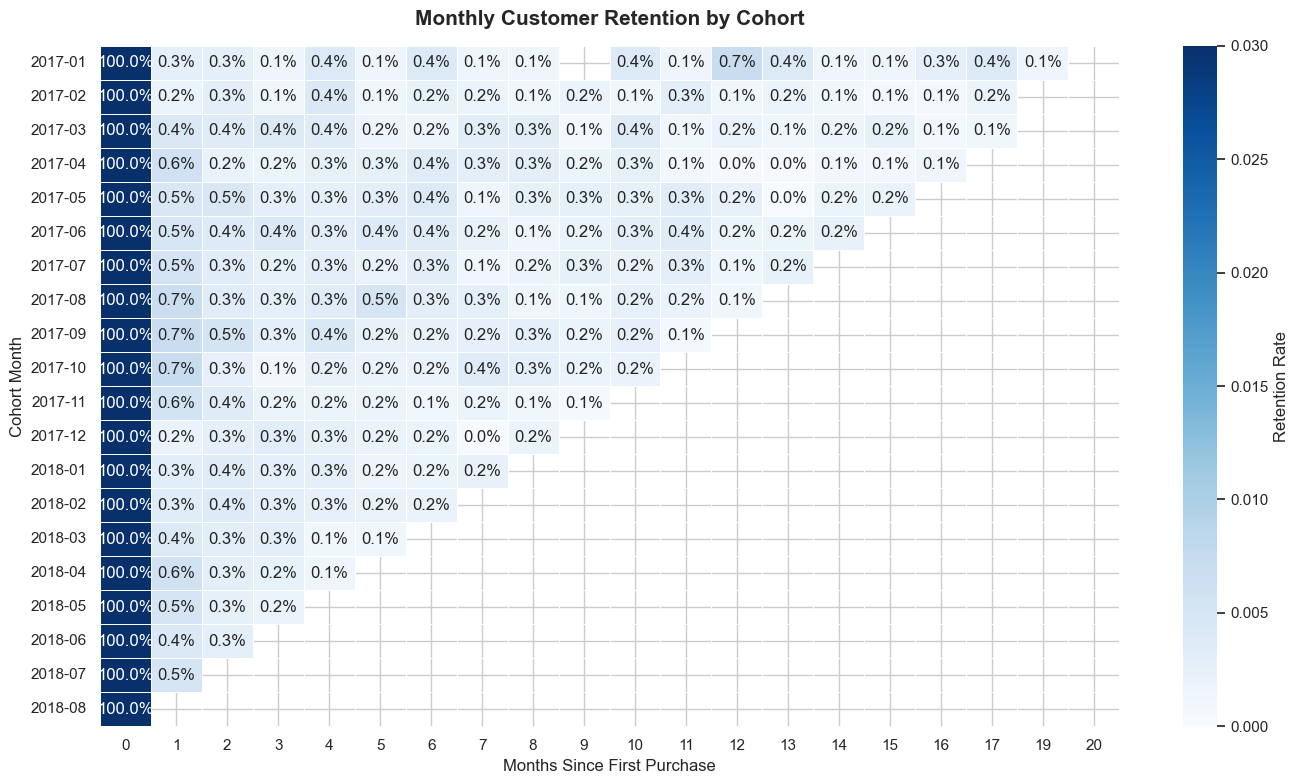

In [17]:
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(
    retention_matrix_filtered,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    vmin=0,
    vmax=0.03,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Retention Rate",
    },
    ax=ax,
)

ax.set_title(
    "Monthly Customer Retention by Cohort",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Months Since First Purchase")
ax.set_ylabel("Cohort Month")

plt.tight_layout()
plt.show()

### Retention heatmap findings

Customer retention is very low across all cohorts.

After the initial purchase month, monthly retention generally remains below 1%. For most cohorts, only around 0.1–0.7% of customers return in a given subsequent month.

The retention pattern is relatively flat and does not show a clear sustained improvement over time. Some cohorts have isolated higher values, but these increases are small and inconsistent.

The triangular shape of the matrix is expected because recent cohorts have been observed for fewer months. Missing values on the right side therefore reflect unavailable future periods rather than missing data.

Overall, the platform depends heavily on one-time purchases, while repeat customer activity remains limited. This confirms the findings from the product metrics analysis.

## 5. Cohort Comparison

In [18]:
cohort_comparison = pd.DataFrame(
    {
        "cohort_month": retention_matrix_filtered.index,
        "month_1_retention": retention_matrix_filtered.get(1),
        "month_3_retention": retention_matrix_filtered.get(3),
        "month_6_retention": retention_matrix_filtered.get(6),
    }
).reset_index(drop=True)

cohort_comparison.head()

,cohort_month,month_1_retention,month_3_retention,month_6_retention
0,2017-01,0.00,0.00,0.00
1,2017-02,0.00,0.00,0.00
2,2017-03,0.00,0.00,0.00
3,2017-04,0.01,0.00,0.00
4,2017-05,0.00,0.00,0.00


In [19]:
cohort_comparison["cohort_month"] = pd.to_datetime(
    cohort_comparison["cohort_month"]
)

In [20]:
month_1_retention = (
    cohort_comparison[
        [
            "cohort_month",
            "month_1_retention",
        ]
    ]
    .dropna()
    .copy()
)

month_1_retention["month_1_retention_percent"] = (
    month_1_retention["month_1_retention"] * 100
)

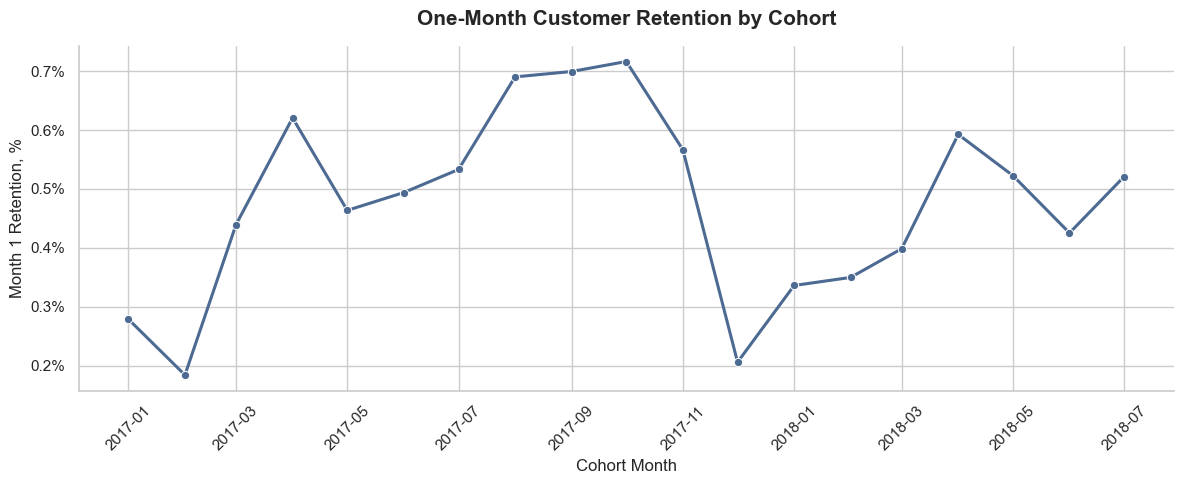

In [21]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.lineplot(
    data=month_1_retention,
    x="cohort_month",
    y="month_1_retention_percent",
    marker="o",
    linewidth=2.2,
    markersize=6,
    color="#4C6A92",
    ax=ax,
)

ax.set_title(
    "One-Month Customer Retention by Cohort",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Cohort Month")
ax.set_ylabel("Month 1 Retention, %")

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{value:.1f}%"
    )
)

sns.despine()
plt.tight_layout()
plt.show()

### One-month retention findings

One-month retention remains very low across all cohorts, ranging approximately from 0.2% to 0.7%.

The strongest results are observed for several cohorts from the second half of 2017, while the December 2017 cohort shows a noticeable drop. Retention improves again during 2018, but still stays below 1%.

The differences between cohorts are visible, but there is no stable upward trend. This suggests that short-term repeat purchasing remained weak throughout the analyzed period.

In [22]:
cohort_comparison_long = (
    cohort_comparison
    .melt(
        id_vars="cohort_month",
        value_vars=[
            "month_1_retention",
            "month_3_retention",
            "month_6_retention",
        ],
        var_name="retention_period",
        value_name="retention_rate",
    )
    .dropna()
)

cohort_comparison_long["retention_period"] = (
    cohort_comparison_long["retention_period"]
    .map(
        {
            "month_1_retention": "Month 1",
            "month_3_retention": "Month 3",
            "month_6_retention": "Month 6",
        }
    )
)

cohort_comparison_long["retention_percent"] = (
    cohort_comparison_long["retention_rate"] * 100
)

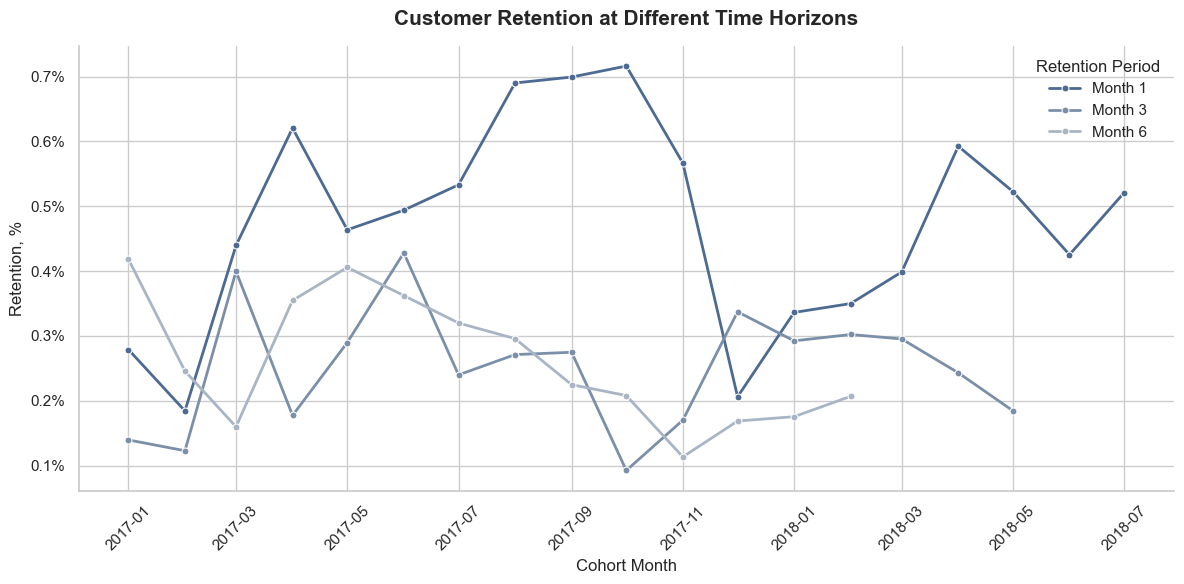

In [23]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.lineplot(
    data=cohort_comparison_long,
    x="cohort_month",
    y="retention_percent",
    hue="retention_period",
    marker="o",
    linewidth=2,
    markersize=5,
    palette=[
        "#4C6A92",
        "#7C8FA8",
        "#A9B5C5",
    ],
    ax=ax,
)

ax.set_title(
    "Customer Retention at Different Time Horizons",
    fontsize=15,
    fontweight="semibold",
    pad=15,
)
ax.set_xlabel("Cohort Month")
ax.set_ylabel("Retention, %")

ax.tick_params(
    axis="x",
    rotation=45,
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda value, _: f"{value:.1f}%"
    )
)

ax.legend(
    title="Retention Period",
    frameon=False,
)

sns.despine()
plt.tight_layout()
plt.show()

### Retention comparison findings

Retention remains low at all analyzed time horizons.

Month 1 retention is generally the highest, but still stays below 1% for every cohort. Month 3 and Month 6 retention are usually lower and fluctuate around approximately 0.1–0.4%.

The gap between Month 1 and the longer horizons indicates that only a small fraction of customers return soon after their first purchase, and even fewer remain active several months later.

There is no consistent improvement across cohorts. Some individual cohorts perform better at specific horizons, but these peaks are isolated and do not form a stable pattern.

Overall, customer retention is weak both in the short term and over longer periods.

### Average Retention by Time Horizon

In [24]:
retention_summary = pd.DataFrame(
    {
        "retention_period": [
            "Month 1",
            "Month 3",
            "Month 6",
        ],
        "average_retention_percent": [
            cohort_comparison["month_1_retention"].mean() * 100,
            cohort_comparison["month_3_retention"].mean() * 100,
            cohort_comparison["month_6_retention"].mean() * 100,
        ],
        "median_retention_percent": [
            cohort_comparison["month_1_retention"].median() * 100,
            cohort_comparison["month_3_retention"].median() * 100,
            cohort_comparison["month_6_retention"].median() * 100,
        ],
        "cohorts_count": [
            cohort_comparison["month_1_retention"].notna().sum(),
            cohort_comparison["month_3_retention"].notna().sum(),
            cohort_comparison["month_6_retention"].notna().sum(),
        ],
    }
)

retention_summary

,retention_period,average_retention_percent,median_retention_percent,cohorts_count
0,Month 1,0.48,0.49,19
1,Month 3,0.25,0.27,17
2,Month 6,0.26,0.24,14


## 6. Key Findings

### Overall cohort retention findings

1. Customer acquisition increased substantially throughout 2017 and then stabilized at approximately 6,000–7,000 new customers per month during most of 2018.

2. Retention is extremely low across all cohorts. In most cases, fewer than 1% of customers return in any given month after their first purchase.

3. One-month retention is generally higher than retention at the three- and six-month horizons, but it still remains below 1% for every cohort.

4. Longer-term retention is weaker and usually fluctuates around approximately 0.1–0.4%.

5. There is no stable improvement in retention across cohorts. Some cohorts perform better at individual horizons, but these differences are inconsistent.

6. The triangular structure of the retention matrix is expected because recent cohorts have shorter observation periods.

7. The platform’s growth was driven primarily by customer acquisition rather than by repeat purchases.

### Business implications

- Retention is a major growth opportunity because even a small increase in repeat purchasing could materially increase customer lifetime value.
- Customers may have weak incentives to return after the first purchase.
- Retention strategies should focus on post-purchase communication, personalized recommendations, loyalty mechanics, and targeted repeat-purchase offers.
- Retention should be analyzed further by product category, region, delivery experience, and customer segment.